# 12 — Final Comparison

This notebook consolidates the results from all previous experiments and performs the final cross-model comparison. It loads saved evaluation outputs only, no models are retrained.

The standard all-generators-seen results are loaded from:

- `03_baseline_cnn.ipynb`
- `04_resnet.ipynb`
- `05_vit.ipynb`
- `08_frequency_models.ipynb`

The leave-one-generator-out (LOGO) results are loaded from:

- `06_leave_one_generator_out.ipynb` for ResNet18 and ViT-Small
- `09_logo_cnn_frequency.ipynb` for the baseline CNN and frequency domain models

Both LOGO notebooks save their outputs to the shared `results/metrics/logo_*/` directories, providing a unified set of results for all five evaluated model families:

- `baseline_cnn`
- `frequency_radial`
- `frequency_hybrid`
- `resnet18`
- `vit_small`

The analyses below compare seen and unseen generator performance using saved aggregate metrics and per-example predictions. They include extended performance metrics, model complexity comparisons, confusion matrices, ROC curves, prediction-confidence and error analysis, generalization-gap analysis and the final evaluation of the project's four research questions (RQ1–RQ4).

The visualizations in this notebook focus on aggregate model behavior, such as error rates, confusion patterns, and ROC performance across generators. Per-example explainability methods, including Grad-CAM and attention rollout, are covered separately in `10_explainability.ipynb` and `11_logo_explainability.ipynb`. Their main findings are referenced in the final discussion where relevant, without reproducing the individual visualizations.

## Load all saved results

Load the standard all-generators-seen evaluation metrics and per-example predictions together with the aggregated LOGO results produced by the preceding experiment notebooks.

The standard evaluation results are loaded from notebooks `03`, `04`, `05` and `08`, while the LOGO results are loaded from notebooks `06` and `09`. The shared `results/metrics/logo_summary.csv` contains the results for all LOGO folds and all five model families, including the corresponding `seen` and `unseen` rows.

In [1]:
import itertools
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, matthews_corrcoef, roc_curve


def find_repo_root(start: Path) -> Path:
    """Find the repository root containing the experiment configuration.

    Args:
        start: Directory from which to start searching for the repository root.

    Returns:
        Path to the repository root.

    Raises:
        FileNotFoundError: If the repository root cannot be found.
    """
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "experiments.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT: Path = find_repo_root(Path.cwd().resolve())

MODEL_ORDER: list[str] = ["baseline_cnn", "frequency_radial", "frequency_hybrid", "resnet18", "vit_small"]
METRIC_NAMES: list[str] = ["accuracy", "precision", "recall", "f1", "roc_auc"]

SEEN_METRIC_PATHS: dict[str, Path] = {
    "baseline_cnn": REPO_ROOT / "results" / "metrics" / "baseline_cnn" / "test_metrics.json",
    "frequency_radial": REPO_ROOT / "results" / "metrics" / "frequency" / "radial" / "test_metrics.json",
    "frequency_hybrid": REPO_ROOT / "results" / "metrics" / "frequency" / "hybrid" / "test_metrics.json",
    "resnet18": REPO_ROOT / "results" / "metrics" / "resnet18" / "test_metrics.json",
    "vit_small": REPO_ROOT / "results" / "metrics" / "vit_small" / "test_metrics.json",
}

SEEN_PREDICTION_PATHS: dict[str, Path] = {
    "baseline_cnn": REPO_ROOT / "results" / "metrics" / "baseline_cnn" / "test_predictions.csv",
    "frequency_radial": REPO_ROOT / "results" / "metrics" / "frequency" / "radial" / "test_predictions.csv",
    "frequency_hybrid": REPO_ROOT / "results" / "metrics" / "frequency" / "hybrid" / "test_predictions.csv",
    "resnet18": REPO_ROOT / "results" / "metrics" / "resnet18" / "test_predictions.csv",
    "vit_small": REPO_ROOT / "results" / "metrics" / "vit_small" / "test_predictions.csv",
}

PER_GENERATOR_PATHS: dict[str, Path] = {
    "baseline_cnn": REPO_ROOT / "results" / "metrics" / "baseline_cnn" / "per_generator_metrics.csv",
    "frequency_radial": REPO_ROOT / "results" / "metrics" / "frequency" / "radial" / "per_generator_metrics.csv",
    "frequency_hybrid": REPO_ROOT / "results" / "metrics" / "frequency" / "hybrid" / "per_generator_metrics.csv",
    "resnet18": REPO_ROOT / "results" / "metrics" / "resnet18" / "per_generator_metrics.csv",
    "vit_small": REPO_ROOT / "results" / "metrics" / "vit_small" / "per_generator_metrics.csv",
}

seen_rows: list[dict[str, float | str]] = []
for model_name, path in SEEN_METRIC_PATHS.items():
    if not path.is_file():
        print(f"Missing seen-generator metrics for {model_name}: {path.relative_to(REPO_ROOT)}")
        continue
    metrics: dict[str, float] = json.loads(path.read_text(encoding="utf-8"))
    seen_rows.append({"model": model_name, **{name: metrics[name] for name in METRIC_NAMES}})

seen_metrics: pd.DataFrame = pd.DataFrame(seen_rows).set_index("model").reindex(MODEL_ORDER)
seen_predictions: dict[str, pd.DataFrame] = {model_name: pd.read_csv(path) for model_name, path in SEEN_PREDICTION_PATHS.items()}

per_generator_frames: list[pd.DataFrame] = []
for model_name, path in PER_GENERATOR_PATHS.items():
    frame: pd.DataFrame = pd.read_csv(path)
    frame.insert(0, "model", model_name)
    per_generator_frames.append(frame)
per_generator_seen: pd.DataFrame = pd.concat(per_generator_frames, ignore_index=True)

logo_summary: pd.DataFrame = pd.read_csv(REPO_ROOT / "results" / "metrics" / "logo_summary.csv")

# Representative LOGO folds selected to illustrate distinct observed generalization patterns in the confusion-matrix analysis. 
# The same generators are used in the complementary explainability notebooks.
REPRESENTATIVE_FOLDS: dict[str, str] = {
    "glide": "intrinsic artifact",
    "wukong": "architectural lineage",
    "midjourney": "neither mechanism",
}
logo_predictions: dict[str, dict[str, pd.DataFrame]] = {
    generator: {
        model_name: pd.read_csv(
            REPO_ROOT / "results" / "metrics" / f"logo_{generator}" / model_name / "test_predictions.csv"
        )
        for model_name in MODEL_ORDER
    }
    for generator in REPRESENTATIVE_FOLDS
}

# Model complexity and inference latency were measured during the original model evaluations 
# and are reused here without re-instantiating or timing the models again. 
# Values are hardcoded to keep this notebook lightweight and avoid downloading pretrained weights on each run.
MODEL_COMPLEXITY: pd.DataFrame = pd.DataFrame(
    [
        {
            "model": "baseline_cnn",
            "architecture": "4-block CNN, trained from scratch",
            "total_parameters": 389_153,
            "trainable_parameters": 389_153,
            "cpu_ms": 30.9,
            "gpu_ms": 2.2,
        },
        {
            "model": "frequency_radial",
            "architecture": "Logistic regression, 64 radial FFT features",
            "total_parameters": 65,
            "trainable_parameters": 65,
            "cpu_ms": 5.9,
            "gpu_ms": np.nan,
        },
        {
            "model": "frequency_hybrid",
            "architecture": "Logistic regression, 320 radial+grid FFT features",
            "total_parameters": 321,
            "trainable_parameters": 321,
            "cpu_ms": 6.4,
            "gpu_ms": np.nan,
        },
        {
            "model": "resnet18",
            "architecture": "ImageNet-pretrained ResNet18, full backbone fine-tuned",
            "total_parameters": 11_177_025,
            "trainable_parameters": 11_177_025,
            "cpu_ms": 63.4,
            "gpu_ms": 8.1,
        },
        {
            "model": "vit_small",
            "architecture": "ImageNet-pretrained ViT-Small/16, last 4 blocks + head fine-tuned",
            "total_parameters": 21_666_049,
            "trainable_parameters": 7_099_009,
            "cpu_ms": 116.4,
            "gpu_ms": 17.4,
        },
    ]
).set_index("model").reindex(MODEL_ORDER)
MODEL_COMPLEXITY["seen_f1"] = seen_metrics["f1"]

print(f"Seen-generator models loaded: {list(seen_metrics.index)}")
print(f"LOGO folds loaded: {sorted(logo_summary['unseen_generators'].unique())}")
print(f"LOGO models loaded: {sorted(logo_summary['model'].unique())}")
print(f"Representative LOGO folds for confusion matrices: {list(REPRESENTATIVE_FOLDS)}")

Seen-generator models loaded: ['baseline_cnn', 'frequency_radial', 'frequency_hybrid', 'resnet18', 'vit_small']
LOGO folds loaded: ['adm', 'biggan', 'glide', 'midjourney', 'sdv1_5', 'sdv1_5+wukong', 'vqdm', 'wukong']
LOGO models loaded: ['baseline_cnn', 'frequency_hybrid', 'frequency_radial', 'resnet18', 'vit_small']
Representative LOGO folds for confusion matrices: ['glide', 'wukong', 'midjourney']


## Standard (seen) comparison table

This table reports accuracy, precision, recall, F1, and ROC-AUC for each model under the standard evaluation setting, where all generators are represented in the training data.

These results provide the baseline for evaluating generalization to unseen generators in the LOGO experiments (RQ1).

In [2]:
display(seen_metrics.round(3))

,accuracy,precision,recall,f1,roc_auc
model,,,,,
baseline_cnn,0.796,0.789,0.809,0.799,0.888
frequency_radial,0.649,0.618,0.778,0.689,0.705
frequency_hybrid,0.708,0.754,0.617,0.679,0.795
resnet18,0.819,0.799,0.852,0.825,0.906
vit_small,0.890,0.881,0.902,0.891,0.957


## Per-generator seen breakdown

Are the generators that perform poorly in LOGO (`adm`, `vqdm`, `midjourney`) already among the hardest generators when they are seen during training?

Each model's notebook (`03`, `04`, `05`, and `08`) saved a `per_generator_metrics.csv` breakdown of the standard test set. These results
are combined into a recall heatmap to compare generator difficulty in the standard seen setting with the corresponding unseen generator performance in the LOGO experiments.

model,baseline_cnn,frequency_radial,frequency_hybrid,resnet18,vit_small
generator,,,,,
biggan,1.000,1.000,1.000,0.960,0.987
glide,1.000,0.987,0.993,0.927,0.973
adm,0.993,0.780,0.553,0.940,0.980
vqdm,0.673,0.600,0.500,0.720,0.820
midjourney,0.453,0.760,0.373,0.707,0.787
sdv1_5,0.773,0.627,0.433,0.860,0.900
wukong,0.767,0.693,0.467,0.853,0.867


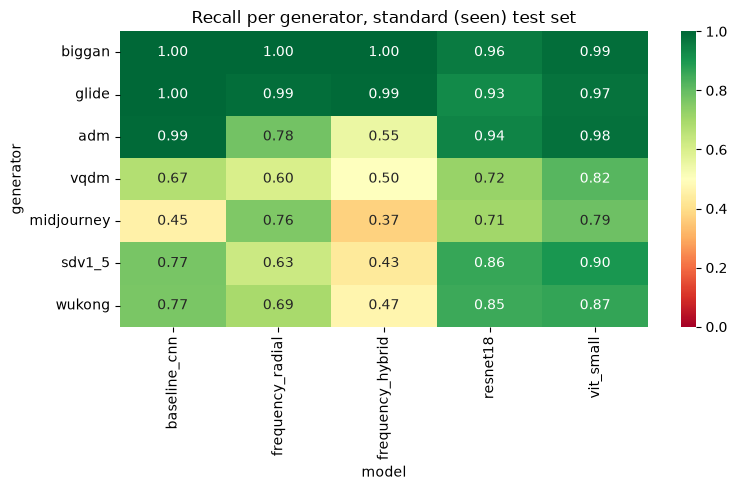

In [3]:
# Same seven generators used in the standard seen-generator evaluation.
# The joint sdv1_5+wukong LOGO fold is excluded because it has no single-generator counterpart for this comparison.
SEEN_GENERATOR_ORDER: list[str] = ["biggan", "glide", "adm", "vqdm", "midjourney", "sdv1_5", "wukong"]

seen_recall_pivot: pd.DataFrame = per_generator_seen.pivot_table(index="generator", columns="model", values="recall").reindex(SEEN_GENERATOR_ORDER)[MODEL_ORDER]
display(seen_recall_pivot.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(seen_recall_pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
ax.set_title("Recall per generator, standard (seen) test set")
plt.tight_layout()
plt.show()

The seen generator results already show substantial differences in generator difficulty. ``biggan`` and ``glide`` are consistently easy to detect across model families, while ``vqdm`` and ``midjourney`` have the lowest average recall across all five models. This pattern is clearest for baseline_cnn, resnet18, and vit_small, where vqdm and midjourney are the two hardest generators for each model individually. The frequency based models show a related but less clean-cut picture: frequency_radial struggles most with ``vqdm`` but not with midjourney (recall 0.760, easier than sdv1_5 and wukong), while frequency_hybrid struggles most with ``midjourney`` but not with ``vqdm`` (recall 0.500, easier than sdv1_5 and wukong). For both frequency models, ``sdv1_5`` is therefore at least as hard as whichever of vqdm/midjourney it is not already struggling with.

The generators that perform poorly in the LOGO setting are therefore not necessarily difficult only because they are unseen. ``vqdm`` and ``midjourney`` already show lower recall when they are represented in the training data, suggesting that their lower performance is not solely caused by the train/test generator shift, as they are already more challenging to detect when seen during training.

However, the LOGO results show that being seen during training still matters: performance can drop substantially when a generator is held out, and the size of this drop varies by model and generator. Overall, these results indicate that generator difficulty and unseen generator generalization are related but distinct factors.

## Statistical significance (seen)

The seen-generator ranking is further evaluated using two complementary
statistical checks, both based only on the saved predictions:

- **Pairwise McNemar's test** - for every pair of models, compares how often they *disagree* on the same test examples (one correct, the other not).
- **Bootstrap confidence intervals** - resamples the test set 1,000 times and computes a 95% confidence interval for each model's F1 score.

McNemar's test is appropriate because all models are evaluated on the same 2,100 examples, making their predictions paired rather than independent.

This analysis is limited to the fixed seen-generator test set. LOGO uncertainty is considered separately through performance variability across held-out generators.

### Pairwise McNemar's test

In [4]:
def mcnemar_pvalue(correct_a: np.ndarray, correct_b: np.ndarray) -> tuple[float, int, int]:
    """Run a continuity-corrected McNemar's test.

    Args:
        correct_a: Boolean array indicating correct predictions by model A.
        correct_b: Boolean array indicating correct predictions by model B.

    Returns:
        Tuple containing the p-value, count where only A is correct, and count where only B is correct.
    """

    only_a_correct: int = int((correct_a & ~correct_b).sum())
    only_b_correct: int = int((~correct_a & correct_b).sum())
    if only_a_correct + only_b_correct == 0:
        return 1.0, only_a_correct, only_b_correct
    statistic: float = (abs(only_a_correct - only_b_correct) - 1) ** 2 / (only_a_correct + only_b_correct)
    p_value: float = float(1 - chi2.cdf(statistic, df=1))
    return p_value, only_a_correct, only_b_correct


# Align predictions by filename so every pair is evaluated on the same 2,100 test examples.
reference_filenames: pd.Series = seen_predictions[MODEL_ORDER[0]].sort_values("filename")["filename"].reset_index(drop=True)
aligned_correct: dict[str, np.ndarray] = {}
for model_name in MODEL_ORDER:
    frame: pd.DataFrame = seen_predictions[model_name].sort_values("filename").reset_index(drop=True)
    assert (frame["filename"] == reference_filenames).all(), f"filename mismatch for {model_name}"
    aligned_correct[model_name] = (frame["label_index"] == frame["prediction_index"]).to_numpy()

mcnemar_rows: list[dict[str, float | int | str | bool]] = []
for model_a, model_b in itertools.combinations(MODEL_ORDER, 2):
    p_value, only_a, only_b = mcnemar_pvalue(aligned_correct[model_a], aligned_correct[model_b])
    mcnemar_rows.append(
        {
            "model_a": model_a,
            "model_b": model_b,
            "only_a_correct": only_a,
            "only_b_correct": only_b,
            "p_value": p_value,
            "significant_at_0.05": p_value < 0.05,
        }
    )
mcnemar_results: pd.DataFrame = pd.DataFrame(mcnemar_rows)
display(mcnemar_results.round(4))

,model_a,model_b,only_a_correct,only_b_correct,p_value,significant_at_0.05
0,baseline_cnn,frequency_radial,474,165,0.0000,True
1,baseline_cnn,frequency_hybrid,348,163,0.0000,True
2,baseline_cnn,resnet18,204,252,0.0277,True
3,baseline_cnn,vit_small,111,308,0.0000,True
4,frequency_radial,frequency_hybrid,222,346,0.0000,True
5,frequency_radial,resnet18,177,534,0.0000,True
6,frequency_radial,vit_small,114,620,0.0000,True
7,frequency_hybrid,resnet18,209,442,0.0000,True
8,frequency_hybrid,vit_small,112,494,0.0000,True
9,resnet18,vit_small,97,246,0.0000,True


All 10 pairwise comparisons are statistically significant at the 0.05 level, including the relatively small difference between `baseline_cnn` and `resnet18` (`p = 0.0277`). This supports that the differences in model predictions on the seen test set are unlikely to be explained by random variation alone.

### Bootstrap confidence intervals

,f1,ci_lower,ci_upper
model,,,
baseline_cnn,0.799,0.777,0.816
frequency_radial,0.689,0.666,0.711
frequency_hybrid,0.679,0.654,0.701
resnet18,0.825,0.808,0.843
vit_small,0.891,0.876,0.905


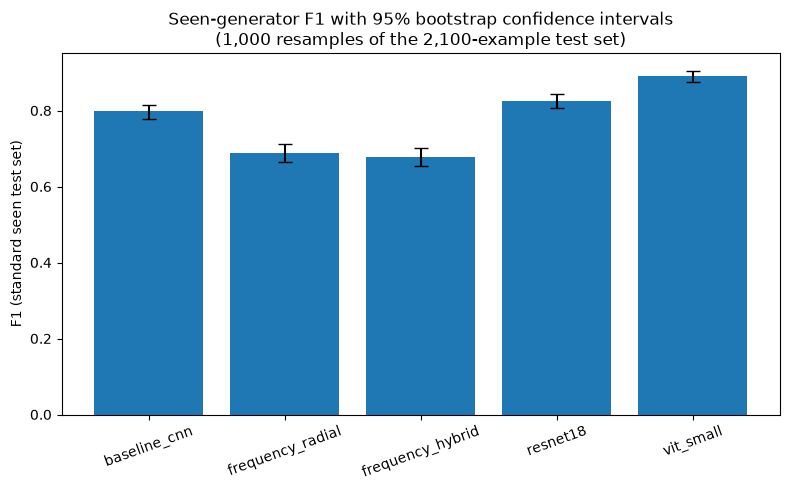

In [5]:
BOOTSTRAP_SEED: int = 42 
N_BOOTSTRAP: int = 1000

rng: np.random.Generator = np.random.default_rng(BOOTSTRAP_SEED)
n_examples: int = len(reference_filenames)

bootstrap_rows: list[dict[str, float | str]] = []
for model_name in MODEL_ORDER:
    frame: pd.DataFrame = seen_predictions[model_name].sort_values("filename").reset_index(drop=True)
    labels: np.ndarray = frame["label_index"].to_numpy()
    predictions: np.ndarray = frame["prediction_index"].to_numpy()
    point_estimate: float = f1_score(labels, predictions)

    bootstrap_f1: np.ndarray = np.empty(N_BOOTSTRAP)
    for i in range(N_BOOTSTRAP):
        sample_indices: np.ndarray = rng.integers(0, n_examples, size=n_examples)
        bootstrap_f1[i] = f1_score(labels[sample_indices], predictions[sample_indices])
    lower, upper = np.percentile(bootstrap_f1, [2.5, 97.5])

    bootstrap_rows.append({"model": model_name, "f1": point_estimate, "ci_lower": lower, "ci_upper": upper})

bootstrap_ci: pd.DataFrame = pd.DataFrame(bootstrap_rows).set_index("model").reindex(MODEL_ORDER)
display(bootstrap_ci.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
lower_error: pd.Series = bootstrap_ci["f1"] - bootstrap_ci["ci_lower"]
upper_error: pd.Series = bootstrap_ci["ci_upper"] - bootstrap_ci["f1"]
ax.bar(bootstrap_ci.index, bootstrap_ci["f1"], yerr=[lower_error, upper_error], capsize=5)
ax.set_ylabel("F1 (standard seen test set)")
ax.set_title(
    f"Seen-generator F1 with 95% bootstrap confidence intervals\n"
    f"({N_BOOTSTRAP:,} resamples of the {n_examples:,}-example test set)"
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The bootstrap intervals are relatively narrow for all models, indicating stable F1 estimates on the seen test set. The intervals also remain clearly separated between the models.

## Extended metrics (seen)

Balanced accuracy and Matthews correlation coefficient (MCC) are computed from the saved per-example predictions. They provide additional evaluation beyond standard accuracy, particularly when errors are unevenly distributed between the two classes.

MCC is especially useful as a single summary measure because it ranges from -1 to 1, with values closer to 1 indicating stronger agreement between predictions and true labels, while values close to 0 indicate little or no correlation between them. Negative values indicate systematic disagreement.

In [6]:
extended_rows: list[dict[str, float | str]] = []
for model_name in MODEL_ORDER:
    frame: pd.DataFrame = seen_predictions[model_name]
    extended_rows.append(
        {
            "model": model_name,
            "balanced_accuracy": balanced_accuracy_score(frame["label_index"], frame["prediction_index"]),
            "mcc": matthews_corrcoef(frame["label_index"], frame["prediction_index"]),
        }
    )
extended_metrics: pd.DataFrame = pd.DataFrame(extended_rows).set_index("model").reindex(MODEL_ORDER)
display(extended_metrics.round(3))

,balanced_accuracy,mcc
model,,
baseline_cnn,0.796,0.593
frequency_radial,0.649,0.309
frequency_hybrid,0.708,0.423
resnet18,0.819,0.640
vit_small,0.890,0.780


The extended metrics confirm the ranking observed with the standard metrics. `vit_small` achieves the strongest balanced accuracy and MCC, followed by `resnet18`, while the frequency-based models perform worst.

The consistency across balanced accuracy, MCC, F1, and ROC-AUC suggests that the observed performance differences are not driven by class-specific errors alone.

## Model complexity

How much model capacity is required to achieve the observed seen-generator performance (RQ3)?

The table compares total and trainable parameters with measured single-image inference latency. For `vit_small`, only the last four transformer blocks and the classification head are trainable, while `resnet18` fine-tunes its full backbone.

Latency was measured once during the original model evaluations and is reused here. For the frequency models, latency includes FFT feature extraction and LogisticRegression `predict_proba`, as they run on CPU only.

,architecture,total_parameters,trainable_parameters,cpu_ms,gpu_ms,seen_f1
model,,,,,,
baseline_cnn,"4-block CNN, trained from scratch",389153,389153,30.9,2.2,0.798683
frequency_radial,"Logistic regression, 64 radial FFT features",65,65,5.9,NaN,0.689161
frequency_hybrid,"Logistic regression, 320 radial+grid FFT features",321,321,6.4,NaN,0.678889
resnet18,"ImageNet-pretrained ResNet18, full backbone fi...",11177025,11177025,63.4,8.1,0.824885
vit_small,"ImageNet-pretrained ViT-Small/16, last 4 block...",21666049,7099009,116.4,17.4,0.891294


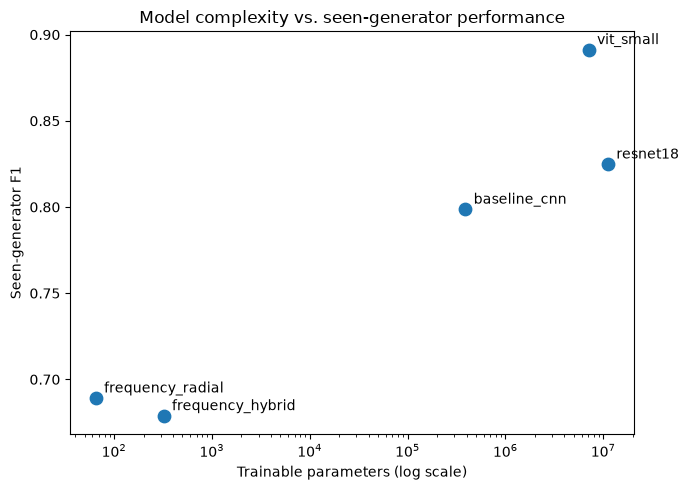

In [7]:
display(MODEL_COMPLEXITY)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(MODEL_COMPLEXITY["trainable_parameters"], MODEL_COMPLEXITY["seen_f1"], s=80)
for model_name, row in MODEL_COMPLEXITY.iterrows():
    ax.annotate(model_name, (row["trainable_parameters"], row["seen_f1"]), textcoords="offset points", xytext=(6, 4))
ax.set_xscale("log")
ax.set_xlabel("Trainable parameters (log scale)")
ax.set_ylabel("Seen-generator F1")
ax.set_title("Model complexity vs. seen-generator performance")
plt.tight_layout()
plt.show()

`vit_small` achieves the highest seen-generator F1, but also has the highest inference latency. The baseline CNN provides a much smaller and faster alternative with only a moderate drop in F1, while the frequency models are by far the lightest but perform substantially worse.

Overall, higher model capacity can improve performance, but with a clear computational cost.

## Confusion matrices (seen)

Where do the models' errors occur: false positives (real images classified as AI) or false negatives (AI images classified as real)?

The confusion matrices are computed directly from the saved predictions so that all five models can be compared on the same scale and test set.

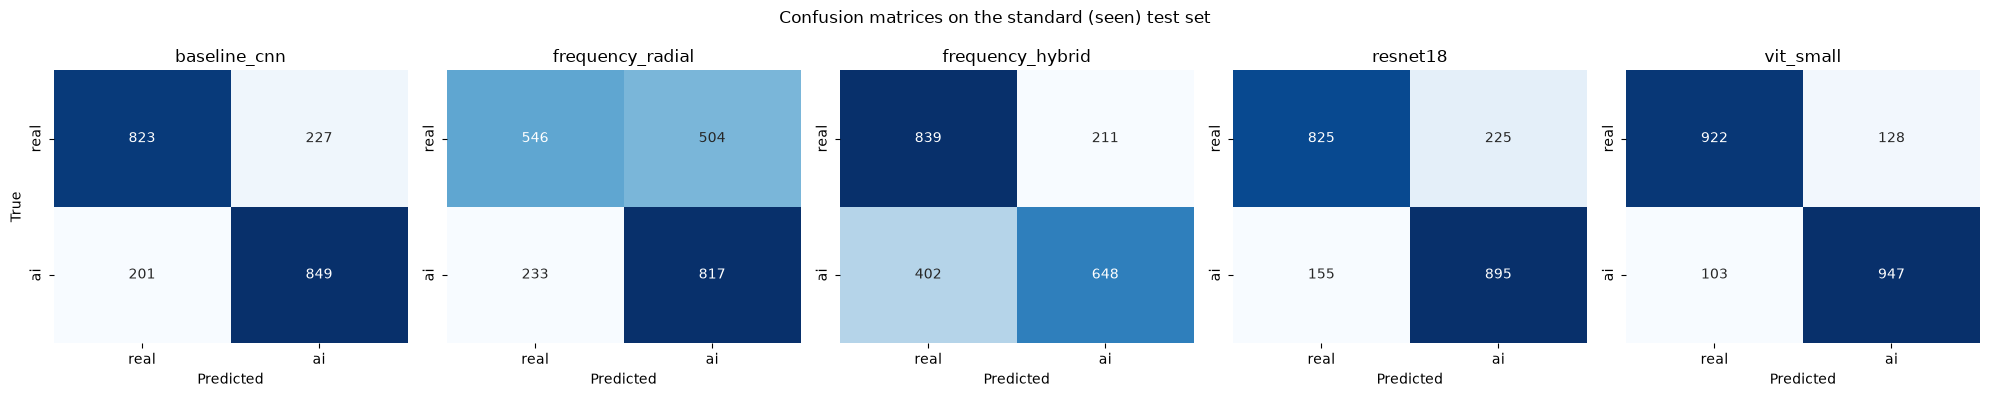

In [8]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4))
for ax, model_name in zip(axes, MODEL_ORDER):
    frame: pd.DataFrame = seen_predictions[model_name]
    matrix: np.ndarray = confusion_matrix(frame["label_index"], frame["prediction_index"], labels=[0, 1])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["real", "ai"],
        yticklabels=["real", "ai"],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if model_name == MODEL_ORDER[0] else "")
fig.suptitle("Confusion matrices on the standard (seen) test set")
plt.tight_layout()
plt.show()

The error patterns differ noticeably across model families. The frequency radial model produces substantially more false positives, while the frequency hybrid model produces more false negatives. The CNN and ResNet18 show more balanced error patterns, with a slight tendency toward false positives. `vit_small` has the fewest false positives and false negatives overall, consistent with its strongest seen-generator performance.

### Error asymmetry

False positives (real images classified as AI) and false negatives (AI images classified as real) have different implications depending on the deployment context. Therefore, both error counts and their corresponding rates are reported rather than relying only on aggregate metrics such as accuracy or F1.

The table below shows the error distribution on the standard seen-generator test set.

In [9]:
error_rows: list[dict[str, int | str]] = []
for model_name in MODEL_ORDER:
    frame: pd.DataFrame = seen_predictions[model_name]
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(frame["label_index"], frame["prediction_index"], labels=[0, 1]).ravel()
    error_rows.append(
        {
            "model": model_name,
            "false_positive (real called AI)": int(false_positive),
            "false_negative (AI called real)": int(false_negative),
            "false_positive_rate": false_positive / (false_positive + true_negative),
            "false_negative_rate": false_negative / (false_negative + true_positive),
        }
    )
error_asymmetry: pd.DataFrame = pd.DataFrame(error_rows).set_index("model").reindex(MODEL_ORDER)
display(error_asymmetry.round(3))

,false_positive (real called AI),false_negative (AI called real),false_positive_rate,false_negative_rate
model,,,,
baseline_cnn,227,201,0.216,0.191
frequency_radial,504,233,0.480,0.222
frequency_hybrid,211,402,0.201,0.383
resnet18,225,155,0.214,0.148
vit_small,128,103,0.122,0.098


On the standard seen test set the asymmetry is modest for most models. It becomes extreme on the hardest LOGO fold, the joint `sdv1_5+wukong` holdout, where recall collapses but precision barely moves, the same pattern shown in the LOGO comparison table above, now split into the two error types it is made of:

In [10]:
joint_error_rows: list[dict[str, int | str]] = []
for model_name in MODEL_ORDER:
    frame: pd.DataFrame = pd.read_csv(REPO_ROOT / "results" / "metrics" / "logo_sdv1_5+wukong" / model_name / "test_predictions.csv")
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(frame["label_index"], frame["prediction_index"], labels=[0, 1]).ravel()
    joint_error_rows.append(
        {
            "model": model_name,
            "false_positive (real called AI)": int(false_positive),
            "false_negative (AI called real)": int(false_negative),
            "false_positive_rate": false_positive / (false_positive + true_negative),
            "false_negative_rate": false_negative / (false_negative + true_positive),
        }
    )
joint_error_asymmetry: pd.DataFrame = pd.DataFrame(joint_error_rows).set_index("model").reindex(MODEL_ORDER)
display(joint_error_asymmetry.round(3))

,false_positive (real called AI),false_negative (AI called real),false_positive_rate,false_negative_rate
model,,,,
baseline_cnn,97,1862,0.092,0.931
frequency_radial,173,1645,0.165,0.822
frequency_hybrid,94,1815,0.090,0.908
resnet18,120,1279,0.114,0.640
vit_small,76,1308,0.072,0.654


The joint holdout produces a strong false-negative imbalance across all models. The effect is most pronounced for `baseline_cnn` and `frequency_hybrid`, with false-negative rates of 0.931 and 0.908 respectively.

`resnet18` and `vit_small` reduce the false-negative rate to 0.640 and 0.654, but still remain substantially more prone to false negatives than false positives.

This explains why precision remains relatively high while recall drops sharply on the joint unseen-generator holdout.

## ROC curves (seen)

ROC curves provide a threshold-independent comparison of the five models on the standard seen-generator test set. The curves show the trade off between the false positive rate and true positive rate across classification thresholds, while the corresponding ROC-AUC values summarize overall ranking performance.

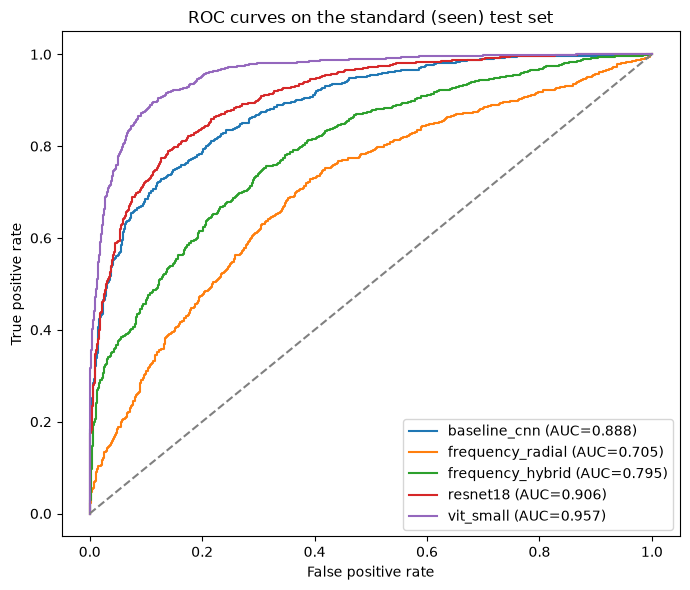

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for model_name in MODEL_ORDER:
    frame: pd.DataFrame = seen_predictions[model_name]
    false_positive_rate, true_positive_rate, _ = roc_curve(frame["label_index"], frame["probability_ai"])
    ax.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC={seen_metrics.loc[model_name, 'roc_auc']:.3f})",
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves on the standard (seen) test set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Prediction confidence and error analysis (seen)

Predicted probabilities provide a useful view of model confidence. The distributions below compare predictions that are correct with those that are incorrect, showing whether errors tend to occur near the 0.5 decision threshold or with higher confidence.

Errors concentrated around 0.5 indicate uncertain predictions, while errors far from the threshold indicate more confident misclassifications.

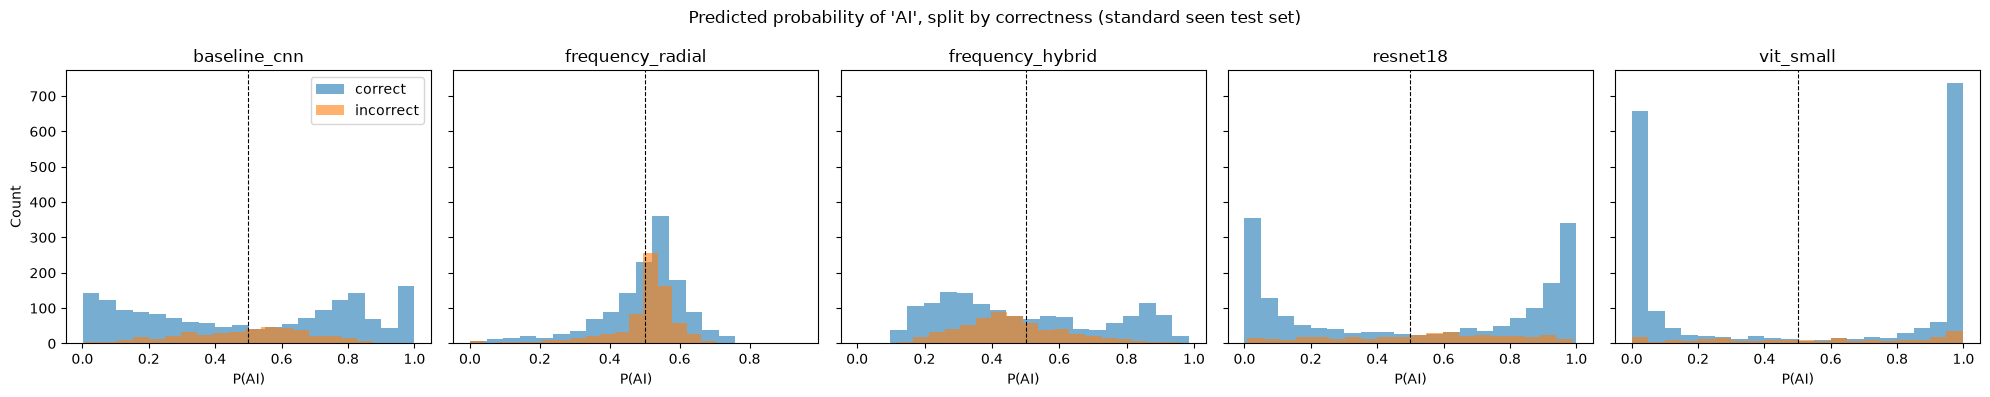

In [12]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4), sharey=True)
for ax, model_name in zip(axes, MODEL_ORDER):
    frame: pd.DataFrame = seen_predictions[model_name].copy()
    frame["correct"] = frame["label_index"] == frame["prediction_index"]
    ax.hist(frame.loc[frame["correct"], "probability_ai"], bins=20, alpha=0.6, label="correct")
    ax.hist(frame.loc[~frame["correct"], "probability_ai"], bins=20, alpha=0.6, label="incorrect")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(model_name)
    ax.set_xlabel("P(AI)")
axes[0].set_ylabel("Count")
axes[0].legend()
fig.suptitle("Predicted probability of 'AI', split by correctness (standard seen test set)")
plt.tight_layout()
plt.show()

The models generally concentrate correct predictions toward the appropriate ends of the probability range, while incorrect predictions are more broadly distributed around the decision threshold.

`vit_small` shows the clearest separation between correct and incorrect predictions, consistent with its stronger overall performance. The frequency models show more overlap between the two distributions, indicating less separation in prediction confidence.

This analysis also highlights that aggregate accuracy alone does not capture how confidently a model makes its errors.

## LOGO (unseen) comparison table

How well do the models generalize when the AI generator is completely unseen during training and model selection (RQ2)?

The table below reports accuracy, precision, recall, F1, and ROC-AUC for every held out generator and model. The joint `sdv1_5+wukong` fold evaluates a more challenging setting in which both generators are excluded simultaneously.

,unseen_generators,model,accuracy,precision,recall,f1,roc_auc
0,biggan,baseline_cnn,0.817,0.822,0.796,0.809,0.901
1,biggan,frequency_radial,0.750,0.753,0.727,0.740,0.851
2,biggan,frequency_hybrid,0.899,0.832,0.992,0.905,0.970
3,biggan,resnet18,0.813,0.807,0.810,0.808,0.887
4,biggan,vit_small,0.871,0.883,0.849,0.865,0.949
5,glide,baseline_cnn,0.864,0.855,0.870,0.862,0.936
6,glide,frequency_radial,0.693,0.722,0.604,0.658,0.805
7,glide,frequency_hybrid,0.898,0.838,0.979,0.903,0.967
8,glide,resnet18,0.831,0.811,0.852,0.831,0.909
9,glide,vit_small,0.906,0.907,0.899,0.903,0.963


model,baseline_cnn,frequency_radial,frequency_hybrid,resnet18,vit_small
unseen_generators,,,,,
biggan,0.796,0.727,0.992,0.810,0.849
glide,0.870,0.604,0.979,0.852,0.899
adm,0.410,0.441,0.467,0.393,0.261
vqdm,0.270,0.258,0.301,0.305,0.280
midjourney,0.152,0.432,0.271,0.380,0.452
sdv1_5,0.466,0.457,0.247,0.734,0.714
wukong,0.393,0.457,0.258,0.705,0.641
sdv1_5+wukong,0.069,0.178,0.092,0.360,0.346


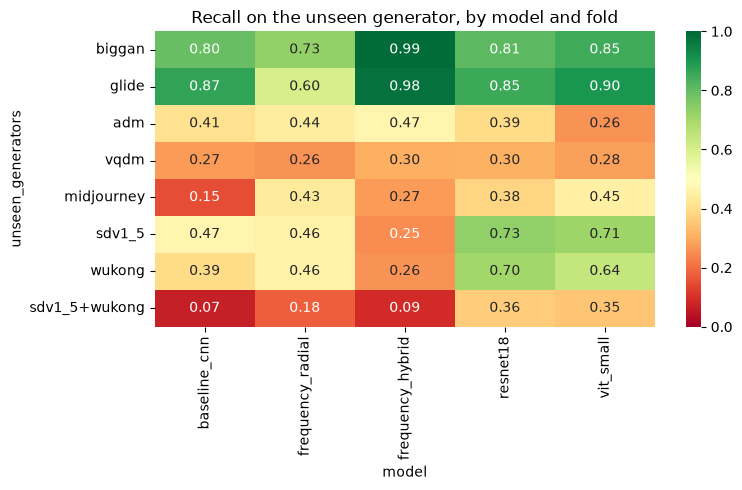

In [13]:
# Fixed order for the single generator LOGO folds followed by the joint holdout.
GENERATOR_ORDER: list[str] = ["biggan", "glide", "adm", "vqdm", "midjourney", "sdv1_5", "wukong", "sdv1_5+wukong"]

unseen_results: pd.DataFrame = logo_summary[logo_summary["split"] == "unseen"].copy()
unseen_results["model"] = pd.Categorical(unseen_results["model"], categories=MODEL_ORDER, ordered=True)
unseen_results["unseen_generators"] = pd.Categorical(unseen_results["unseen_generators"], categories=GENERATOR_ORDER, ordered=True)
unseen_results = unseen_results.sort_values(["unseen_generators", "model"]).reset_index(drop=True)

display(unseen_results[["unseen_generators", "model", *METRIC_NAMES]].round(3))

# Recall highlights how many unseen AI-generated images are detected.
recall_pivot: pd.DataFrame = unseen_results.pivot_table(index="unseen_generators", columns="model", values="recall", observed=True).reindex(GENERATOR_ORDER)[MODEL_ORDER]
display(recall_pivot.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(recall_pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
ax.set_title("Recall on the unseen generator, by model and fold")
plt.tight_layout()
plt.show()

Generalization varies substantially across both generators and model
families.

- `biggan` and `glide` are detected relatively well by most models, with recall reaching 0.992 and 0.979 for `frequency_hybrid`.
- `vqdm` is consistently difficult, with recall below 0.31 for every model.
- `midjourney` is also challenging, although `vit_small` performs better than the other models with 0.452 recall and 0.833 ROC-AUC.
- `sdv1_5` and `wukong` show a clear advantage for the deep models, particularly `resnet18` and `vit_small`.
- The joint `sdv1_5+wukong` holdout causes a substantial drop in recall for all models, with the best recall reaching only 0.360 for `resnet18`.

Overall, no single model generalizes best across all unseen generators. Performance depends strongly on the held out generator and on the model representation used.

## Confusion matrices on representative LOGO folds

The confusion matrices below show the actual error counts for three representative LOGO folds: `glide`, `wukong`, and `midjourney`.

These folds were selected in notebooks `06` and `09` to represent different generalization behaviors observed across the experiments. The same folds are also used in the explainability analyses from `10_explainability.ipynb` and `11_logo_explainability.ipynb`, allowing the aggregate error patterns shown here to be related to the corresponding per-example explanations.

Only these three folds are shown to keep the comparison readable, the remaining LOGO folds are represented in the aggregate tables above.

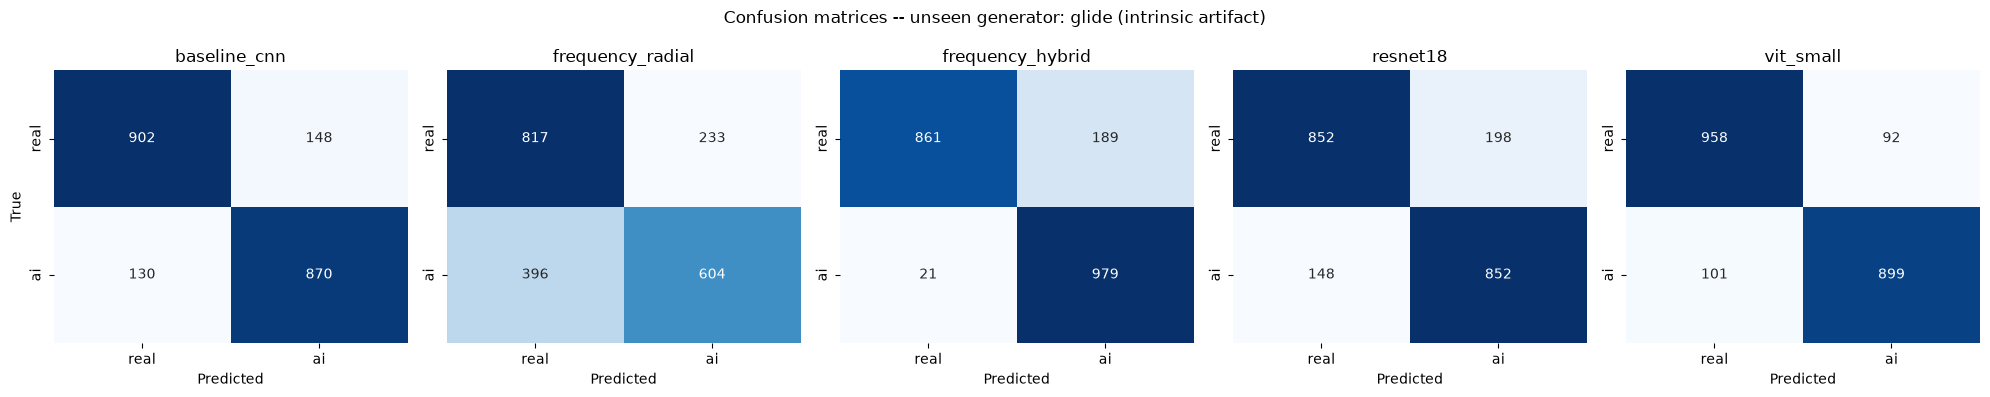

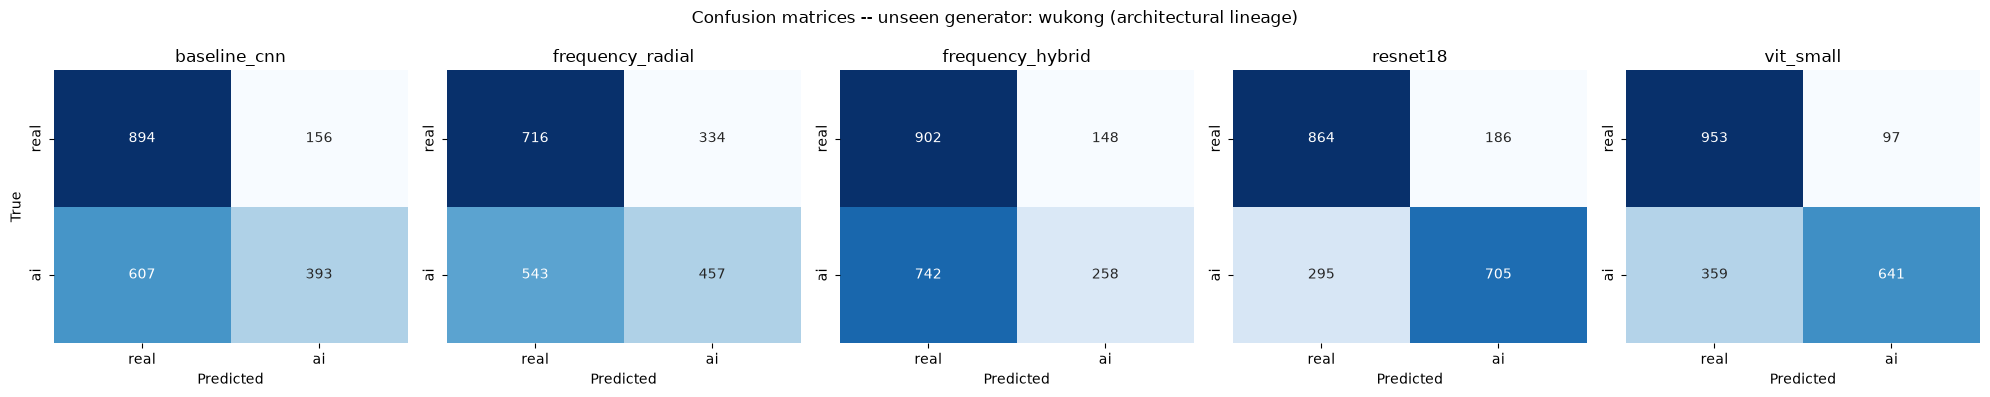

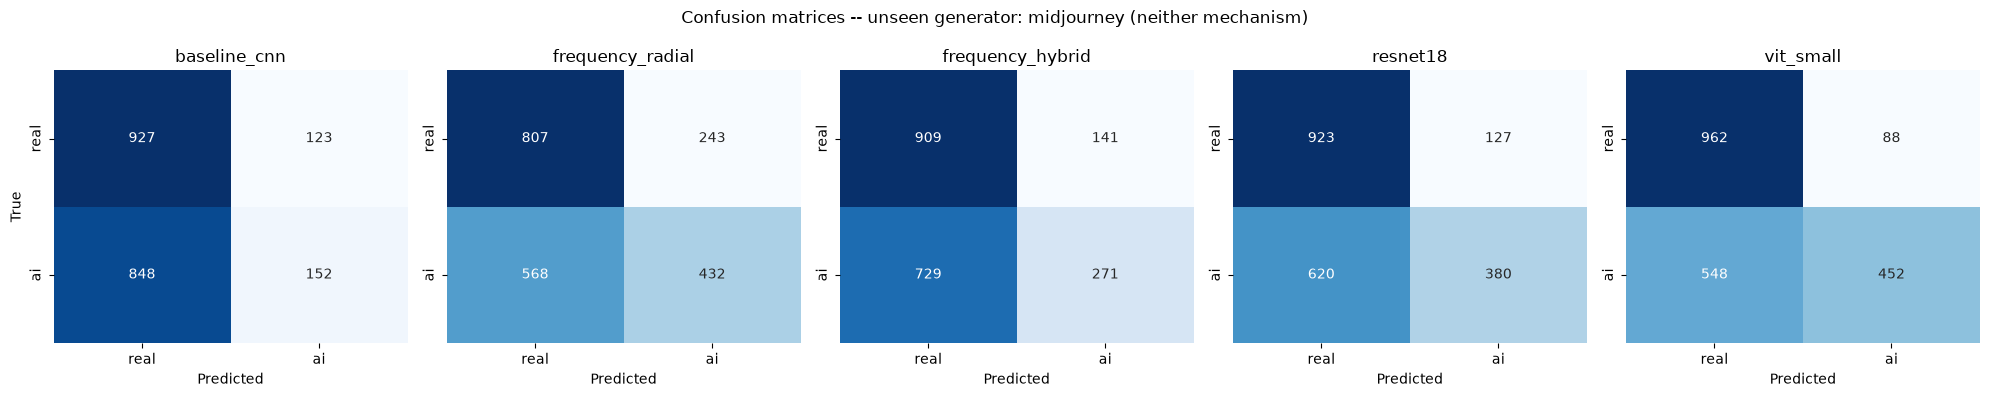

In [14]:
for generator, mechanism in REPRESENTATIVE_FOLDS.items():
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4))
    for ax, model_name in zip(axes, MODEL_ORDER):
        frame: pd.DataFrame = logo_predictions[generator][model_name]
        matrix = confusion_matrix(frame["label_index"], frame["prediction_index"], labels=[0, 1])
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["real", "ai"],
            yticklabels=["real", "ai"],
            ax=ax,
        )
        ax.set_title(model_name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True" if model_name == MODEL_ORDER[0] else "")
    fig.suptitle(f"Confusion matrices -- unseen generator: {generator} ({mechanism})")
    plt.tight_layout()
    plt.show()

The representative folds illustrate three distinct error patterns.

- **`glide`** is detected relatively well across models, but the error balance differs substantially.
- **`wukong`** produces substantially more false negatives than false positives for all models. `vit_small` has the fewest false positives while `resnet18` and `vit_small` retain the strongest overall recall among the models.
- **`midjourney`** shows the strongest false-negative imbalance. `vit_small` performs best among the evaluated models, but still produces 548 false negatives out of 1,000 AI images.

These examples reinforce that aggregate accuracy or F1 alone does not fully describe unseen generator behavior. The type of error also varies by generator and model family, which is important when considering how an AI image detector would be used in practice.

## Generalization Gap

The generalization gap measures how much performance changes when moving from the standard seen generator setting to the unseen generator LOGO setting.

For each model and LOGO fold, the pooled gap is defined as:

generalization_gap = overall_seen_F1 - unseen_F1

Here, overall_seen_F1 is the model's F1 score on the standard test set containing all seven generators, while unseen_F1 is the F1 score on the corresponding held out generator.

A positive gap indicates a drop in F1 when the generator is unseen, while a negative gap indicates that the unseen score is slightly higher than the overall seen score.

This pooled comparison provides a simple summary of the generalization effect. However, it does not account for the fact that different generators have different levels of detection difficulty in the seen setting. Therefore, a matched per generator analysis is reported in the following section.

model,baseline_cnn,frequency_radial,frequency_hybrid,resnet18,vit_small
unseen_generators,,,,,
biggan,-0.010,-0.050,-0.226,0.017,0.026
glide,-0.064,0.032,-0.224,-0.006,-0.012
adm,0.298,0.164,0.111,0.325,0.501
vqdm,0.417,0.353,0.268,0.397,0.481
midjourney,0.560,0.173,0.295,0.321,0.304
sdv1_5,0.228,0.176,0.324,0.053,0.098
wukong,0.291,0.179,0.312,0.079,0.154
sdv1_5+wukong,0.675,0.408,0.517,0.317,0.391


,mean,std
model,,
baseline_cnn,0.246,0.222
frequency_radial,0.147,0.127
frequency_hybrid,0.123,0.248
resnet18,0.169,0.171
vit_small,0.222,0.210


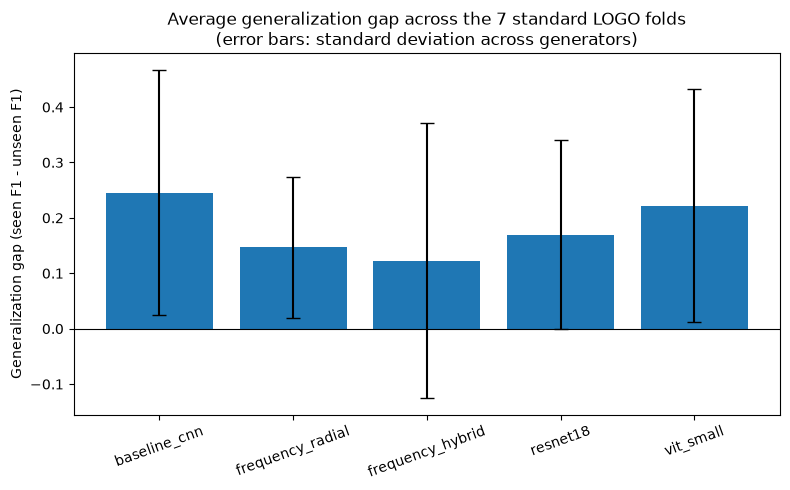

In [15]:
# Compare each unseen generator F1 with the model's overall seen generator F1.
seen_f1: pd.DataFrame = logo_summary[logo_summary["split"] == "seen"][["model", "f1"]].drop_duplicates("model")
generalization_gap: pd.DataFrame = unseen_results.merge(seen_f1, on="model", suffixes=("", "_seen"))
generalization_gap["generalization_gap"] = generalization_gap["f1_seen"] - generalization_gap["f1"]

gap_pivot: pd.DataFrame = generalization_gap.pivot_table(
    index="unseen_generators", columns="model", values="generalization_gap", observed=True
).reindex(GENERATOR_ORDER)[MODEL_ORDER]
display(gap_pivot.round(3))

is_standard_fold: pd.Series = generalization_gap["unseen_generators"] != "sdv1_5+wukong"
gap_stats: pd.DataFrame = (
    generalization_gap[is_standard_fold]
    .groupby("model", observed=True)["generalization_gap"]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)
display(gap_stats.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(gap_stats.index, gap_stats["mean"], yerr=gap_stats["std"], capsize=5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Generalization gap (seen F1 - unseen F1)")
ax.set_title(
    "Average generalization gap across the 7 standard LOGO folds\n"
    "(error bars: standard deviation across generators)"
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The pooled generalization gap shows substantial variation across generators and model families.
frequency_hybrid has the smallest mean gap (0.123).

However, the mean gap should not be interpreted in isolation. The frequency models also have lower absolute F1 on the standard test set, so a smaller difference between seen and unseen performance does not necessarily indicate
better overall generalization.

The variability across generators is also important. frequency_hybrid has a particularly large standard deviation (0.248), indicating that its generalization behavior is highly dependent on the held out generator. resnet18 shows a more moderate and stable gap, while vit_small combines strong absolute performance with a relatively larger average drop.

The pooled gap is therefore useful as a high level summary, but it can be confounded by differences in generator difficulty. The matched
per generator gap below provides a more direct comparison.

### Matched per generator gap

The pooled gap compares each unseen generator score with the model's overall seen generator performance. This can be misleading because generators differ in difficulty even when they are included in training.

To control for this, the matched gap compares each held out generator with that same generator's F1 score in the standard seen generator evaluation:

matched_gap = same_generator_seen_F1 - unseen_F1

This measures the performance degradation associated with withholding a specific generator, rather than comparing it with an average across all generators.

Only the seven single-generator LOGO folds are included. The joint sdv1_5+wukong holdout is excluded because it does not have a single
same generator seen baseline.

model,baseline_cnn,frequency_radial,frequency_hybrid,resnet18,vit_small
unseen_generators,,,,,
biggan,0.106,0.069,0.007,0.086,0.068
glide,0.039,0.121,-0.003,0.022,0.021
adm,0.370,0.159,0.057,0.365,0.529
vqdm,0.350,0.259,0.179,0.327,0.432
midjourney,0.319,0.165,0.095,0.227,0.235
sdv1_5,0.187,0.069,0.170,0.052,0.100
wukong,0.267,0.144,0.200,0.088,0.156


,mean,std
model,,
baseline_cnn,0.234,0.127
frequency_radial,0.141,0.065
frequency_hybrid,0.101,0.084
resnet18,0.167,0.139
vit_small,0.220,0.192


Negative matched gaps (unseen genuinely better than that generator's own seen score): 1 out of 35 fold/model combinations.


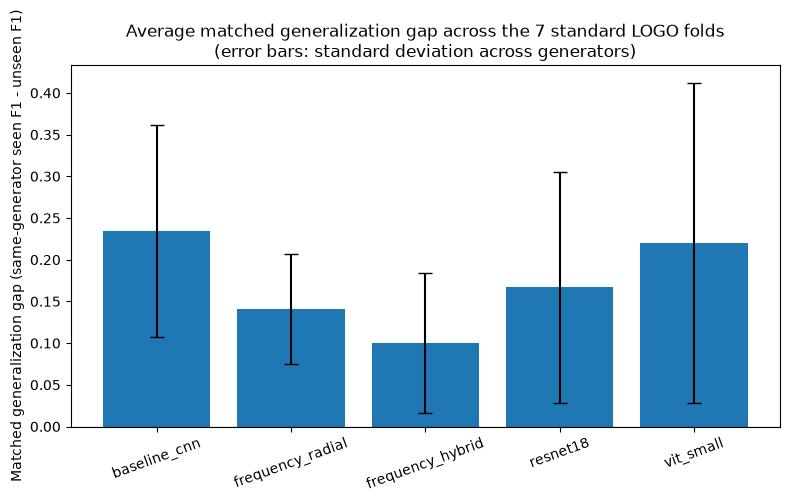

In [16]:
# F1 for each generator in the standard seen-generator evaluation.
matched_seen_f1: pd.DataFrame = per_generator_seen.pivot_table(index="generator", columns="model", values="f1").reindex(SEEN_GENERATOR_ORDER)[MODEL_ORDER]

# Convert the seen generator scores to long format for matching with LOGO folds.
matched_seen_f1_long: pd.DataFrame = matched_seen_f1.stack().rename("f1_seen_matched").reset_index()
matched_seen_f1_long.columns = ["unseen_generators", "model", "f1_seen_matched"]

matched_gap: pd.DataFrame = unseen_results.merge(matched_seen_f1_long, on=["unseen_generators", "model"])
matched_gap["matched_generalization_gap"] = matched_gap["f1_seen_matched"] - matched_gap["f1"]

# Match each LOGO fold with the same generator's seen F1.
# The joint sdv1_5+wukong fold is automatically excluded because it has no corresponding single-generator seen baseline.
matched_gap_pivot: pd.DataFrame = matched_gap.pivot_table(
    index="unseen_generators", columns="model", values="matched_generalization_gap", observed=True
).reindex(SEEN_GENERATOR_ORDER)[MODEL_ORDER]
display(matched_gap_pivot.round(3))

matched_gap_stats: pd.DataFrame = (matched_gap.groupby("model", observed=True)["matched_generalization_gap"].agg(["mean", "std"]).reindex(MODEL_ORDER))
display(matched_gap_stats.round(3))

print(f"Negative matched gaps (unseen genuinely better than that generator's own seen score): "
      f"{int((matched_gap_pivot < 0).sum().sum())} out of {matched_gap_pivot.size} fold/model combinations.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(matched_gap_stats.index, matched_gap_stats["mean"], yerr=matched_gap_stats["std"], capsize=5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Matched generalization gap (same-generator seen F1 - unseen F1)")
ax.set_title(
    "Average matched generalization gap across the 7 standard LOGO folds\n"
    "(error bars: standard deviation across generators)"
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The matched analysis provides a more direct measure of generator-specific generalization because each unseen score is compared with the same
generator's seen performance. frequency_hybrid has the smallest mean matched gap.

The ranking is similar to the pooled analysis, but the matched gaps are generally smaller because the comparison accounts for the intrinsic
difficulty of each generator. The difference is particularly noticeable for frequency_hybrid, whose standard deviation decreases from 0.248 in the pooled analysis to 0.084 in the matched analysis. This suggests that much of the variability in its pooled gap was related to differences in generator difficulty rather than only to the effect of holding the generator out.

The largest matched gaps are observed for the more challenging generator/model combinations, particularly adm, vqdm, and midjourney
for several models. This confirms that generalization difficulty is strongly generator-dependent.

Only 1 of the 35 matched model/fold combinations has a negative gap: frequency_hybrid on glide (-0.003). This means that its unseen F1 is
slightly higher than its seen F1 for that generator. The difference is very small and should not be interpreted as evidence that withholding the generator improves performance.

### Robustness check: does the matched F1 gap survive the seen side sample size?

The matched gap compares two evaluations based on different sample sizes. The seen generator F1 is computed from the same 300 example matched slice used for the per generator seen analysis (150 AI and 150 matched real examples), whereas the unseen F1 is computed on the full LOGO fold containing approximately 1,000 AI and 1,050 real examples.

Because the seen-side estimate is based on a relatively small sample, the matched gap may be affected by sampling variability. This robustness check therefore evaluates whether the observed F1 gap remains distinguishable from zero when uncertainty from both sides of the comparison is taken into account.

For each of the 35 model/generator combinations, the analysis performs 2,000 bootstrap resamples independently on the seen and unseen predictions, using the original sample size on each side. The F1 score is recomputed for each resample and the difference between the matched seen F1 and unseen F1 is recorded.

A 95% bootstrap interval that excludes zero indicates that the observed gap is not consistent with zero within the uncertainty estimated from these samples. An interval containing zero means that the observed gap cannot be clearly distinguished from zero at this sample size.

The analysis uses the same F1 definition as the matched-gap analysis and resamples the complete real-plus-AI evaluation on both sides. It therefore tests the robustness of the matched F1 gap itself rather than a related quantity such as AI-only recall.

In [17]:
def _fast_f1(labels: np.ndarray, predictions: np.ndarray) -> float:
    """Compute binary F1 without sklearn's per-call overhead."""

    true_positive = np.sum((labels == 1) & (predictions == 1))
    false_positive = np.sum((labels == 0) & (predictions == 1))
    false_negative = np.sum((labels == 1) & (predictions == 0))
    denominator = 2 * true_positive + false_positive + false_negative
    return float(2 * true_positive / denominator) if denominator > 0 else 0.0


N_GAP_BOOTSTRAP: int = 2000
gap_rng: np.random.Generator = np.random.default_rng(BOOTSTRAP_SEED)

gap_robustness_rows: list[dict[str, float | str | bool]] = []
for generator in SEEN_GENERATOR_ORDER:
    for model_name in MODEL_ORDER:
        seen_frame = seen_predictions[model_name]
        # Reproduce the same 300-example matched seen slice used by
        # per_generator_seen and matched_seen_f1.
        seen_matched = seen_frame[
            ((seen_frame["label"] == "ai") & (seen_frame["generator"] == generator))
            | ((seen_frame["label"] == "real") & (seen_frame["source_group"] == generator))
        ]
        seen_labels: np.ndarray = seen_matched["label_index"].to_numpy()
        seen_preds: np.ndarray = seen_matched["prediction_index"].to_numpy()

        # Use the complete unseen LOGO fold, including both real and AI examples, matching the F1 reported in logo_summary.
        unseen_frame = pd.read_csv(REPO_ROOT / "results" / "metrics" / f"logo_{generator}" / model_name / "test_predictions.csv")
        unseen_labels: np.ndarray = unseen_frame["label_index"].to_numpy()
        unseen_preds: np.ndarray = unseen_frame["prediction_index"].to_numpy()

        n_seen, n_unseen = len(seen_labels), len(unseen_labels)
        point_gap = _fast_f1(seen_labels, seen_preds) - _fast_f1(unseen_labels, unseen_preds)

        gap_samples: np.ndarray = np.empty(N_GAP_BOOTSTRAP)
        for i in range(N_GAP_BOOTSTRAP):
            seen_idx = gap_rng.integers(0, n_seen, n_seen)
            unseen_idx = gap_rng.integers(0, n_unseen, n_unseen)
            gap_samples[i] = _fast_f1(seen_labels[seen_idx], seen_preds[seen_idx]) - _fast_f1(
                unseen_labels[unseen_idx], unseen_preds[unseen_idx]
            )

        ci_lower, ci_upper = np.percentile(gap_samples, [2.5, 97.5])
        gap_robustness_rows.append(
            {
                "generator": generator,
                "model": model_name,
                "f1_gap": point_gap,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "crosses_zero": bool(ci_lower <= 0 <= ci_upper),
            }
        )

gap_robustness: pd.DataFrame = pd.DataFrame(gap_robustness_rows)
not_significant: pd.DataFrame = gap_robustness[gap_robustness["crosses_zero"]]
print(
    f"F1 gaps not distinguishable from zero at this sample size: "
    f"{len(not_significant)} out of {len(gap_robustness)}"
)
display(not_significant[["generator", "model", "f1_gap", "ci_lower", "ci_upper"]].round(3))
display(gap_robustness.round(3))

F1 gaps not distinguishable from zero at this sample size: 7 out of 35


,generator,model,f1_gap,ci_lower,ci_upper
2,biggan,frequency_hybrid,0.007,-0.030,0.040
5,glide,baseline_cnn,0.039,-0.002,0.074
7,glide,frequency_hybrid,-0.003,-0.040,0.030
8,glide,resnet18,0.022,-0.027,0.065
9,glide,vit_small,0.021,-0.015,0.052
12,adm,frequency_hybrid,0.057,-0.023,0.124
26,sdv1_5,frequency_radial,0.069,-0.002,0.136


,generator,model,f1_gap,ci_lower,ci_upper,crosses_zero
0,biggan,baseline_cnn,0.106,0.066,0.142,False
1,biggan,frequency_radial,0.069,0.023,0.117,False
2,biggan,frequency_hybrid,0.007,-0.030,0.040,True
3,biggan,resnet18,0.086,0.042,0.123,False
4,biggan,vit_small,0.068,0.033,0.102,False
5,glide,baseline_cnn,0.039,-0.002,0.074,True
6,glide,frequency_radial,0.121,0.065,0.172,False
7,glide,frequency_hybrid,-0.003,-0.040,0.030,True
8,glide,resnet18,0.022,-0.027,0.065,True
9,glide,vit_small,0.021,-0.015,0.052,True


Seven of the 35 matched F1 gaps have 95% bootstrap intervals that contain zero. These are concentrated in relatively small gap cases: four of the five models on glide, biggan/frequency_hybrid, adm/frequency_hybrid, and sdv1_5/frequency_radial.

The glide results are particularly informative. Most models have a verysmall matched gap on this generator, and the bootstrap intervals indicate that these differences cannot be clearly distinguished from zero given the small 300 example seen-side sample. This suggests that the apparent gap on these folds should not be overinterpreted.

In contrast, the remaining 28 of 35 matched gaps have intervals that exclude zero. This includes all of the larger gaps, such as those observed for adm, vqdm, and midjourney across several models. These larger generator specific performance drops therefore remain visible even after accounting for sampling variability in the smaller seen-side evaluation.

Overall, the robustness check shows that the sample size asymmetry does not fully explain the matched gap results. It does, however, introduce uncertainty for the smallest observed gaps, which should be interpreted cautiously.

## Frequency Domain Generalization Summary (RQ4)

Does frequency domain information improve generalization to unseen generators?

The frequency-based models, frequency_radial and frequency_hybrid, are compared with the RGB-based models (baseline_cnn, resnet18, and
vit_small) using two complementary measures.

First, the matched F1 gap measures how much performance degrades relative to the same generator's seen performance. A smaller gap indicates less degradation under the generator shift. This comparison covers the seven single generator LOGO folds, where a matched seen baseline is available.

Second, absolute recall measures how many AI-generated images from the unseen generator are detected. This metric is reported across all eight LOGO folds, including the joint sdv1_5+wukong holdout.

Using both measures is important. A model can have a small matched gap simply because its seen generator performance is already relatively low. Therefore, the matched gap measures robustness to the generator shift, while absolute recall measures the actual detection capability on unseen AI images.

In [18]:
# Compare the best frequency-domain model with the best RGB-based model.
# Smaller matched F1 gap indicates less degradation.
frequency_best_gap: pd.Series = matched_gap_pivot[["frequency_radial", "frequency_hybrid"]].min(axis=1)
rgb_best_gap: pd.Series = matched_gap_pivot[["baseline_cnn", "resnet18", "vit_small"]].min(axis=1)

frequency_gap_wins: pd.Series = frequency_best_gap < rgb_best_gap
gap_comparison: pd.DataFrame = pd.DataFrame(
    {
        "frequency_best_gap": frequency_best_gap,
        "rgb_best_gap": rgb_best_gap,
        "frequency_wins": frequency_gap_wins,
    }
)

display(gap_comparison.round(3))

print(
    "Matched gap: frequency domain models have the smaller gap on "
    f"{int(frequency_gap_wins.sum())} of "
    f"{len(frequency_gap_wins)} standard LOGO folds."
)

# Compare the best frequency domain model with the best RGB based model.
# Higher recall means more unseen AI images are detected.
frequency_best_recall: pd.Series = recall_pivot[["frequency_radial", "frequency_hybrid"]].max(axis=1)
rgb_best_recall: pd.Series = recall_pivot[["baseline_cnn", "resnet18", "vit_small"]].max(axis=1)

frequency_recall_wins: pd.Series = (frequency_best_recall > rgb_best_recall)
recall_comparison: pd.DataFrame = pd.DataFrame(
    {
        "frequency_best_recall": frequency_best_recall,
        "rgb_best_recall": rgb_best_recall,
        "frequency_wins": frequency_recall_wins,
    }
)

display(recall_comparison.round(3))

print(
    "Absolute recall: frequency domain models have the higher recall on "
    f"{int(frequency_recall_wins.sum())} of "
    f"{len(frequency_recall_wins)} LOGO folds."
)

,frequency_best_gap,rgb_best_gap,frequency_wins
unseen_generators,,,
biggan,0.007,0.068,True
glide,-0.003,0.021,True
adm,0.057,0.365,True
vqdm,0.179,0.327,True
midjourney,0.095,0.227,True
sdv1_5,0.069,0.052,False
wukong,0.144,0.088,False


Matched gap: frequency domain models have the smaller gap on 5 of 7 standard LOGO folds.


,frequency_best_recall,rgb_best_recall,frequency_wins
unseen_generators,,,
biggan,0.992,0.849,True
glide,0.979,0.899,True
adm,0.467,0.410,True
vqdm,0.301,0.305,False
midjourney,0.432,0.452,False
sdv1_5,0.457,0.734,False
wukong,0.457,0.705,False
sdv1_5+wukong,0.178,0.360,False


Absolute recall: frequency domain models have the higher recall on 3 of 8 LOGO folds.


The frequency domain models often degrade less relative to their own seen generator performance, but this does not translate into stronger absolute detection of unseen AI generated images. In particular, frequency_hybrid has relatively low seen generator F1 on several generators, so a small matched gap can coexist with weak absolute unseen performance.

Therefore, the results do not support the conclusion that frequency domain information consistently improves unseen generator
detection. Instead, frequency based representations appear to provide some robustness to generator shift in terms of relative performance degradation, while the strongest absolute unseen generator detection is generally achieved by the RGB based deep models, particularly resnet18 and vit_small.

## Final conclusions

The experiments evaluated five model families across both standard seen generator classification and leave one-generator out (LOGO) generalization. The results show that strong in-distribution performance does not necessarily translate into robust detection of unseen generators, and that the effectiveness of a representation depends strongly on the type of generator being evaluated.

### RQ1 - Baseline

All five model families distinguish real from AI generated images reasonably well when all generators are represented during training, but their performance differs substantially.

vit_small achieves the strongest seen generator performance
(F1 = 0.891, ROC-AUC = 0.957), followed by resnet18
(F1 = 0.825, ROC-AUC = 0.906), baseline_cnn
(F1 = 0.799, ROC-AUC = 0.888), frequency_radial
(F1 = 0.689, ROC-AUC = 0.705), and frequency_hybrid
(F1 = 0.679, ROC-AUC = 0.795).

The frequency domain models therefore provide a substantially weaker representation for the standard seen generator task than the learned RGB models. Even the relatively small baseline_cnn outperforms both frequency based models, while the pretrained deep models achieve the
strongest overall discrimination.

The differences are supported by paired statistical analysis. McNemar's test finds all 10 model pairs significantly different at the 0.05 level, with the closest comparison being baseline_cnn versus resnet18 (p = 0.0277). Bootstrap 95% confidence intervals for F1 are also relatively narrow, indicating stable estimates on the seen test set.

The per generator breakdown shows that performance is not uniform across generators. biggan and glide are consistently easy to detect, while
vqdm and midjourney are substantially more challenging even when they are represented during training. This already indicates that generator
difficulty is an important factor in the later LOGO results.

### RQ2 - Generalization

Generalization to unseen generators varies substantially across both generators and model families. The matched per generator analysis provides the most appropriate comparison for the seven single generator LOGO folds,
because each unseen score is compared with the same generator's seen F1.

The mean matched generalization gap ranges from 0.101 for frequency_hybrid to 0.234 for baseline_cnn. However, a smaller gap does
not necessarily indicate stronger absolute detection performance, because models begin from different seen generator performance levels.

The generator specific results reveal much stronger variation than the model averages alone suggest. biggan and glide show very small matched gaps for several models, whereas adm, vqdm, and midjourney produce substantially larger degradation for most model families. The joint sdv1_5+wukong holdout is particularly challenging, with all models showing a large reduction in F1 relative to their overall seen generator performance.

The earlier pooled gap analysis produced apparently negative gaps for some biggan and glide results. The matched analysis shows why those values should not be interpreted as improved unseen performance: these generators already have higher F1 in the seen generator breakdown than the harder generators, so comparing them with the overall pooled seen score introduces a generator difficulty confound.

After matching each unseen generator to its own seen performance, only one of the 35 model/generator combinations has a negative gap:
frequency_hybrid on glide (-0.003). The bootstrap robustness analysis shows that its 95% interval contains zero, so this small difference is not distinguishable from no performance change at the available sample size.

Overall, the LOGO experiments demonstrate that generalization is strongly generator dependent rather than being determined by a single universal model ranking.

### RQ3 - Architecture

No single architecture is uniformly best across all aspects of unseen generator performance. The ranking depends on whether robustness is measured as relative degradation or as absolute detection performance.

By mean matched generalization gap, frequency_hybrid has the smallest gap (0.101), followed by frequency_radial (0.141), resnet18 (0.167),
vit_small (0.220), and baseline_cnn (0.234). frequency_radial also has the lowest standard deviation across the seven matched folds (0.065),
indicating the most consistent gap according to this particular measure.

However, absolute unseen recall leads to a different conclusion. The frequency models perform particularly well on biggan, glide, and adm,
but the strongest recall on the remaining LOGO folds is generally achieved by the deep RGB models. resnet18 and vit_small achieve the highest recall on five of the eight LOGO folds, including sdv1_5, wukong, and the joint sdv1_5+wukong holdout.

This distinction is important: a model can have a small generalization gap because its performance is already relatively low on the seen generator. Therefore, matched gap is useful for measuring relative robustness, but absolute unseen recall is more informative when the practical objective is to detect as many unseen AI-generated images as possible.

baseline_cnn is the weakest overall architecture in the LOGO comparison. It has the largest mean matched gap (0.234) and is not the best model on any of the evaluated folds. Its performance is therefore not simply the result of one unusually difficult generator. It remains comparatively weak across the LOGO evaluation.

Model complexity also does not provide a simple explanation for the ranking. The models differ dramatically in parameter count and inference cost, yet neither parameter count nor latency alone predicts generalization. frequency_hybrid, for example, contains only 321 parameters and is highly competitive on biggan and glide, while baseline_cnn has approximately 389K parameters but performs worse overall. Conversely, the much larger pretrained resnet18 and vit_small provide substantially stronger absolute detection on several difficult unseen generators.

These results suggest that the learned representation and the relationship between the training and unseen generator distributions are more important than model capacity alone.

### RQ4 - Frequency information

The results do not support frequency domain information as a universal solution to unseen generator detection. Its effectiveness depends strongly on the generator and on how generalization is measured.

Using the matched generalization gap, a frequency domain model has the smaller gap on 5 of the 7 standard single generator LOGO folds:
biggan, glide, adm, vqdm, and midjourney. This indicates that frequency based representations can retain a relatively larger fraction of
their seen generator performance on several generator shifts.

However, absolute unseen recall gives a more practically relevant picture. Frequency-domain models achieve the highest recall on only 3 of the 8 LOGO folds: biggan, glide, and adm. On vqdm, midjourney, sdv1_5, wukong, and the joint sdv1_5+wukong holdout, an RGB based model achieves higher recall.

The difference between these two analyses is important. A smaller matched gap does not necessarily mean that the frequency model detects more unseen AI images. The frequency models start from lower seen generator F1 values on several generators, leaving less absolute performance to lose.

The strongest frequency domain result is therefore generator specific rather than universal. frequency_hybrid is particularly effective on biggan and glide, and also achieves the best recall among the five models on adm. In contrast, it performs poorly on the sdv1_5 and wukong folds, where deep RGB models provide substantially stronger detection.

Thus, the experiments provide evidence that frequency-domain information can be useful for certain generator shifts, but they do not show that it consistently improves unseen-generator detection across the full set of evaluated generators.

### Tying back to the central question

The central question of this project is whether an AI generated image detector can remain robust when evaluated on generative models that were completely unseen during training.

The experiments show that this is possible for some generator shifts, but not uniformly across all generators. The dominant source of variation is not simply the choice of architecture: the same model can perform extremely well on one unseen generator and poorly on another.

Three broad patterns emerge from the LOGO experiments.

1. **Generators with highly transferable artifacts: biggan and glide** - These generators are detected relatively well even when held out from training. frequency_hybrid is particularly strong, with matched F1 gaps close to zero on both generators. This suggests that some detectable characteristics transfer well across the generator boundary.
2. **Architectural lineage: sdv1_5 and wukong** - These folds show a different pattern. The deep RGB models retain much stronger absolute recall than the frequency domain models, suggesting that learned visual representations can capture information that transfers between related generators more effectively than the handcrafted spectral representations used here.
3. **Neither mechanism: `adm`, `vqdm` and `midjourney`** - These generators expose substantial weaknesses in generalization for several model families. Even the strongest models experience significant degradation, showing that good seen generator performance alone is not
sufficient evidence of robustness.

**Explainability cross-check:** 
The qualitative findings from 10_explainability.ipynb and 11_logo_explainability.ipynb support the same three way pattern observed in
the quantitative LOGO results.

First, the number of images misclassified by all five evaluated models on the same representative folds increases from 13 on glide to 143 on wukong and 243 on midjourney. This mirrors the quantitative difficulty gradient and shows that the difference between these folds is not driven by a single model's weakness, but is shared across model families.

The frequency-model results reported in the explainability analysis also match the aggregate results in this notebook. frequency_hybrid achieves F1 = 0.9031 and ROC-AUC = 0.9670 on glide, compared with F1 = 0.3670 on wukong and 0.3836 on midjourney. This is consistent with its near zero matched gap on glide and its substantially weaker absolute performance on the more difficult folds.

The example level explanations provide additional insight into these differences. In a shared wukong texture example, the radial frequency model classifies the image as real with high confidence while the hybrid model classifies it as AI. This illustrates how retaining the full two-dimensional frequency representation can capture information that is lost when the spectrum is reduced to a radial representation.

The ViT attention rollout examples provide another complementary observation: vit_small identifies some wukong and midjourney images that both convolutional models classify as real. This is qualitatively consistent with the stronger recall achieved by resnet18 and vit_small on several of the difficult LOGO folds.

At the same time, some realistic midjourney images are classified as real by all evaluated models. This reinforces the quantitative finding that midjourney remains one of the most difficult unseen generators and that changing the architecture alone does not eliminate the generalization problem.

Across the explainability analyses, no single explanation pattern spatial, attention based, or spectral remains stable across all representative folds. The qualitative evidence therefore supports the broader quantitative conclusion that generalization is generator dependent rather than determined by one universal detection strategy.

**Practical implication - which error matters more:** 
The aggregate metrics treat false positives and false negatives equally, but their practical consequences may differ substantially in a real deployment.

The LOGO error analysis shows that the hardest joint sdv1_5+wukong holdout produces a strong false negative imbalance. For example, baseline_cnn produces 1,862 false negatives among 2,000 AI images, corresponding to a false negative rate of 93.1%, while its false positive rate is only 9.2%.

This indicates that the main failure mode on the hardest unseen generator setting is not excessive rejection of real images, but failure to detect AI generated images. A deployment system should therefore not select a classification threshold solely from aggregate accuracy or F1. The relative cost of false positives and false negatives should be considered explicitly, and threshold selection should be evaluated on representative unseen generators.

### Conclusion 

The main conclusion of this study is that robust AI image detection across unseen generators is strongly generator dependent.

The pretrained deep models, particularly vit_small and resnet18, provide the strongest overall performance on both the standard seen generator task and most difficult unseen generator folds. Frequency domain models are much smaller and computationally efficient, and can be highly effective for specific generator shifts such as biggan and glide, but their advantage does not generalize consistently across the full set of unseen generators.

The results also demonstrate why seen generator performance alone is an insufficient measure of detector quality. Models that achieve strong
in distribution scores can experience substantial performance degradation when the generator changes. Evaluating models with LOGO therefore reveals generalization behavior that would remain hidden under a conventional random train/test split.

Overall, the experiments support a generator aware view of AI image detection: robustness depends on the relationship between the training
generators, the unseen generator, and the representation learned by the model. No single architecture or feature representation consistently solves the unseen generator problem across all evaluated cases.